In [1]:
import numpy as np
import sklearn
%matplotlib inline
import matplotlib as mpl 
import matplotlib.pyplot as plt

First of all the dataset is read and, from it, the feature (X) and label (y) arrays are created.

In [2]:
import pandas as pd

df = pd.read_csv('HIGGS.csv.gz', header=None, nrows=500_000)

In [3]:
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values        

The following commands are used to get a handle on the dataset, its structure and the values of its features.

In [4]:
X.shape

(500000, 28)

In [5]:
y.shape

(500000,)

In [6]:
X[0]

array([ 0.86929321, -0.63508183,  0.22569026,  0.32747006, -0.6899932 ,
        0.75420225, -0.24857314, -1.0920639 ,  0.        ,  1.37499213,
       -0.65367419,  0.93034911,  1.10743606,  1.13890433, -1.57819831,
       -1.04698539,  0.        ,  0.65792954, -0.01045457, -0.04576717,
        3.10196137,  1.35376   ,  0.97956312,  0.97807616,  0.92000484,
        0.72165745,  0.98875093,  0.87667835])

In [7]:
y[0]

np.float64(1.0)

Then, the dataset is split into training, validation and testing groups. Considering also the labels, the next commands form 6 arrays. In this case, 20% of the full dataset is assigned to the testing, while 10% of the training set is kept for validation. 42 fixes the shuffling of the dataset so that it is reproducible. 

In [8]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.10, random_state=42)

In [9]:
X_train.shape

(360000, 28)

In [10]:
X_train[0]

array([ 0.50675219, -1.93630409,  1.19725251,  1.1616472 , -0.51051551,
        0.55981171, -0.64070421, -1.15748024,  0.        ,  1.0115087 ,
       -0.82852143,  0.1175234 ,  0.        ,  1.58305073,  0.37792608,
       -1.66773415,  0.        ,  0.54644907, -1.05398214,  1.22064507,
        3.10196137,  1.20424306,  0.87814856,  1.06235862,  0.73145169,
        0.22785209,  0.50989568,  0.8288936 ])

The next command is used to visualise the different variables. In order to have a more complete view of their values, scatter plots are made for each feature, for the first 500 events, resulting in the plots visible below.

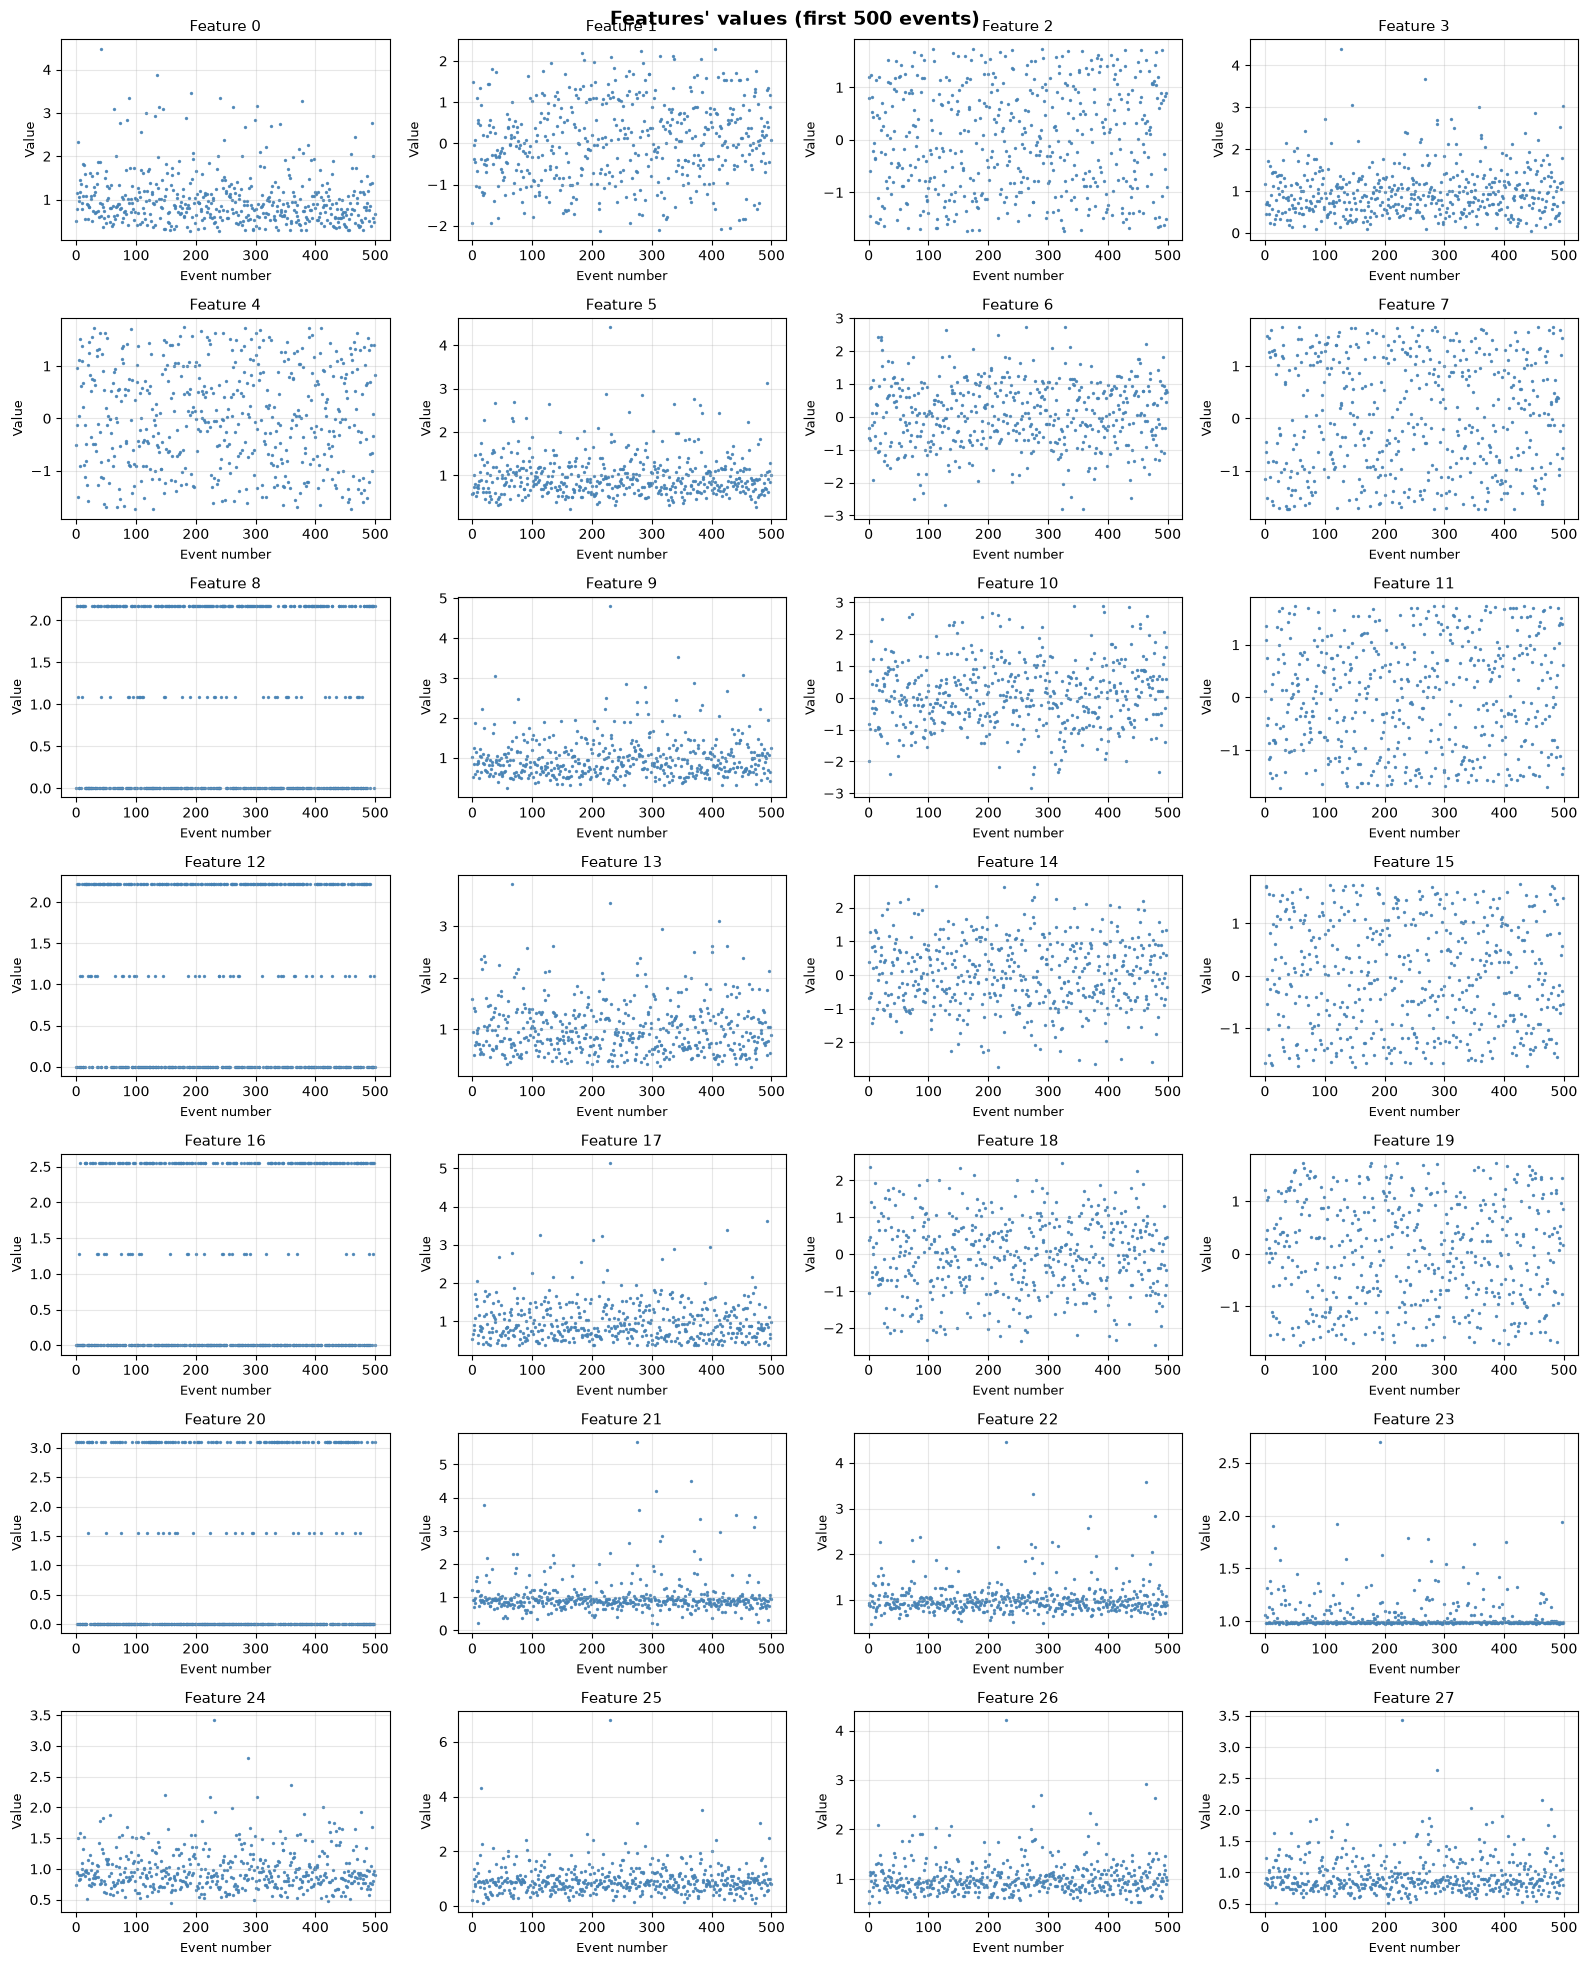

In [11]:
import matplotlib.pyplot as plt

n_events = 500
X_sample = X_train[:n_events]  # first 500 events, all 28 features

fig, axes = plt.subplots(7, 4, figsize=(16, 20))  # 7 rows × 4 cols = 28 plots
axes = axes.flatten()  # makes it easier to index

for j in range(28):
    col_j = X_sample[:, j]  # all 500 values for feature j
    axes[j].scatter(range(n_events), col_j, s=2, color='steelblue', alpha=0.85)
    axes[j].set_title(f"Feature {j}", fontsize=11)
    axes[j].set_xlabel("Event number", fontsize=9)
    axes[j].set_ylabel("Value", fontsize=9)
    axes[j].grid(True, alpha=0.3)

plt.suptitle("Features' values (first 500 events)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The first Boosted Decision Tree model has just the basic parameters defined, those being "max_bins", and "max_iter". The first one determines the number of bins of the histograms which are built to discretise the features' values in order to make the training faster (255 is the default value). "max_iter", instead, is the maximum number of iterations of the boosting process, i.e. the maximum number of trees for binary classification. "validation_fraction" = 0.1 sets 10% of the training dataset for internal validation. 

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

higgs_BDT_0 = HistGradientBoostingClassifier(max_bins=255, max_iter=100, validation_fraction=0.1) 

In [13]:
%%time

higgs_BDT_0.fit(X_train, y_train)

CPU times: user 28.9 s, sys: 313 ms, total: 29.2 s
Wall time: 5.19 s


,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dty

In [14]:
y_pred = higgs_BDT_0.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.738


In [15]:
y_pred = higgs_BDT_0.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f"val_accuracy: {val_acc:.3f}")

val_accuracy: 0.729


In [16]:
y_pred = higgs_BDT_0.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.729


The accuracy shown by this first model can be considered good, given the simplicity of the algorithm. 

The first attempt to improve the Boosted Decision Tree results was made inserting and defining three other more parameters of the model: "max_depth", "learning_rate" and "l2_regularization". The depth of a tree is the number of edges to go from the root to the deepest leaf. So "max_depth" is the maximum depth of each tree. "learning_rate", also known as "shrinkage", is used as a multiplicative factor for the leaves values: "learning_rate" = 0.1 means that the prediction given by each tree is weighted only as the 10%. Finally, "l2_regularization" penalizes complexity to prevent overfitting by not allowing leaves to have large corrections if the data don't provide strong evidence for it. In the previous model (higgs_BDT_0) these three parameters had been maskedly set to their default values respectively of "None", "0.1" and "0", while in higgs_BDT_1 they have been kept the same as the default ones for "learning_rate" and "l2_regularization" and "max_depth" has been set to "3". In this way the only difference between the previous model and the following one is the different setting of the "max_depth" parameter. 

In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier  
from sklearn.metrics import accuracy_score

higgs_BDT_1 = HistGradientBoostingClassifier(max_bins=255, max_iter=100, validation_fraction=0.1, max_depth=3, learning_rate=0.1, l2_regularization=0) 

In [18]:
%%time

higgs_BDT_1.fit(X_train, y_train)

CPU times: user 15.6 s, sys: 249 ms, total: 15.8 s
Wall time: 2.78 s


,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",3
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [19]:
y_pred = higgs_BDT_1.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.716


In [20]:
y_pred = higgs_BDT_1.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f"val_accuracy: {val_acc:.3f}")

val_accuracy: 0.713


In [21]:
y_pred = higgs_BDT_1.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.711


The setting of a maximum value for the depth of the model seems to have worsened the performance of the algorithm, as it can be seen by the lower value of the accuracy. The fact that both training and test accuracies are lower than in the previous model seems to suggest that with no depth limit the trees would have developed further than just three, so imposing a maximum value worsened the structure of the classifier. 

For this reason, in the next model (higgs_BDT_2) the "max_depth" parameter has been set to 5, hoping to target the cause of the failing of the previous algorithm. 

In [22]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_2 = HistGradientBoostingClassifier(max_bins=255, max_iter=100, validation_fraction=0.1, max_depth=5, learning_rate=0.1, l2_regularization=0)

In [23]:
%%time

higgs_BDT_2.fit(X_train, y_train)

CPU times: user 21.2 s, sys: 317 ms, total: 21.6 s
Wall time: 3.76 s


,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",5
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [24]:
y_pred = higgs_BDT_2.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.733


In [25]:
y_pred = higgs_BDT_2.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.726


In [26]:
y_pred = higgs_BDT_2.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.724


The increase in the value of the parameter describing the maximum depth reachable by a tree seems to have led to positive results, indicated by the improvements in the computed accuracies. 

With the goal of developing a more efficient algorithm, the next model follows the improvement obtained by higgs_BDT_2 and further increases "max_depth" to 7. 

In [27]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_3 = HistGradientBoostingClassifier(max_bins=255, max_iter=100, validation_fraction=0.1, max_depth=7, learning_rate=0.1, l2_regularization=0)

In [28]:
%%time

higgs_BDT_3.fit(X_train, y_train)

CPU times: user 23.3 s, sys: 169 ms, total: 23.5 s
Wall time: 4.03 s


,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [29]:
y_pred = higgs_BDT_3.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.737


In [30]:
y_pred = higgs_BDT_3.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.729


In [31]:
y_pred = higgs_BDT_3.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.727


The increase in the "max_depth" parameter did indeed correspond to an increase in the calculated accuracies for this model. Further tests have been done to verify if a larger maximum depth of the trees would have further improved the accuracy, but the improvements were too minimal to justify a significant increase in this parameter value. "max_depth" = 7 has so been considered the best setting for this feature of the algorithm. 

The next models have so focused on other parameters of the tree, starting from the number of trees ("max_iter"), which has been set to 200 in the next algorithm higgs_BDT_4. 

In [32]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_4 = HistGradientBoostingClassifier(max_bins=255, max_iter=200, validation_fraction=0.1, max_depth=7, learning_rate=0.1, l2_regularization=0)

In [33]:
%%time

higgs_BDT_4.fit(X_train, y_train)

CPU times: user 38.6 s, sys: 240 ms, total: 38.9 s
Wall time: 6.6 s


,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [34]:
y_pred = higgs_BDT_4.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.746


In [35]:
y_pred = higgs_BDT_4.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.733


In [36]:
y_pred = higgs_BDT_4.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.731


Increasing the value of the "max_iter" parameter led to a striking increase in all the computed accuracies, signaling the importance of the number of trees in the development of a boosted decision tree algorithm. In fact, this parameter describes the complexity of the model and so allows for a sharper distinction between signal and background. 

Given these results, another model was trained after having set "max_iter" to an even higher value: 300. 

In [37]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_5 = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.1, l2_regularization=0)

In [38]:
%%time

higgs_BDT_5.fit(X_train, y_train)

CPU times: user 56.8 s, sys: 520 ms, total: 57.4 s
Wall time: 9.71 s


,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [39]:
y_pred = higgs_BDT_5.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.753


In [40]:
y_pred = higgs_BDT_5.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.734


In [41]:
y_pred = higgs_BDT_5.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.734


Similarly as the "max_depth" parameter, also for the "max_iter" case, a sort of "saturation" is reached, after which the improvements in the model's accuracies are much smaller than the parameter's increase. After having tried even larger values, "max_iter" = 300 seems the best option.   

The next step it to modify the learning rate parameter, which defines how much each tree contributes to the training of the algorithm. Usually the combination of a large number of trees and a small learning rate leads to a better model because each tree contributes only a small correction to the cumulative score, making the learning process more gradual and reducing the risk of any single tree's error dominating the final result. This needs to be compensated by a larger number of trees since each one contributes less. For this reason, the next model, higgs_BDT_6, was trained imposing "learning_rate" = 0.05. 

In [42]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_6 = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.05, l2_regularization=0)

In [43]:
%%time

higgs_BDT_6.fit(X_train, y_train)

CPU times: user 1min 2s, sys: 639 ms, total: 1min 3s
Wall time: 10.8 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""

In [44]:
y_pred = higgs_BDT_6.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.742


In [45]:
y_pred = higgs_BDT_6.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.731


In [46]:
y_pred = higgs_BDT_6.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.731


Surprisingly, decreasing the learning rate led to a worse performance of the model. This could be caused by what was mentioned earlier: maybe a number of trees equal to 300 is not large enough to allow for a learning rate as small as 0.05. To test this hypothesis, first the number of trees was set to 1000, then the "n_iter_no_change" parameter was introduced and set, conventionally, to 10. This feature tells the algorithm to stop adding trees if there is no improvement in the validation accuracy after ten consecutive trees. In this way the model determines the optimal number of trees automatically, which will then be inspected via the "n_iter_" attribute. 

In [47]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_7 = HistGradientBoostingClassifier(max_bins=255, max_iter=1000, validation_fraction=0.1, max_depth=7, learning_rate=0.05, l2_regularization=0, n_iter_no_change=10)

In [48]:
%%time

higgs_BDT_7.fit(X_train, y_train)

CPU times: user 2min 6s, sys: 832 ms, total: 2min 7s
Wall time: 21.5 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",1000
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype"

In [49]:
y_pred = higgs_BDT_7.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.756


In [50]:
y_pred = higgs_BDT_7.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.736


In [51]:
y_pred = higgs_BDT_7.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.735


In [52]:
print(f"Trees used: {higgs_BDT_7.n_iter_}")

Trees used: 683


As expected, the required number of trees for a so small value of the learning rate was much higher than the previous 300, and by a large amount. This increase has in this way allowed to have an improvement in the accuracy, although not high as hoped.  

Given these poor results, which seem to not justify further increasing the number of trees, in the subsequent model, higgs_BDT_8, the "max_iter" parameter was set again to 300 and, for testing purposes, the learning rate was increased to 0.2. In this way checking if indeed the accuracy would have worsened as expected.

In [53]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_8 = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.2, l2_regularization=0)

In [54]:
%%time

higgs_BDT_8.fit(X_train, y_train)

CPU times: user 37.8 s, sys: 320 ms, total: 38.1 s
Wall time: 6.57 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.2
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [55]:
y_pred = higgs_BDT_8.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.759


In [56]:
y_pred = higgs_BDT_8.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.736


In [57]:
y_pred = higgs_BDT_8.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.735


Surprisingly, the training accuracy actually increased with respect to higgs_BDT_5, the best model so far, with a lower learning rate than higgs_BDT_8. The cause of this behaviour is probably to be found in the reasoning made earlier about the number of trees. Given the fact that "max_iter" = 300 seems to be a small value for this parameter, probably this algorithm works better with a high learning rate of 0.2. For this reason, the next models will keep this last value for "learning_rate". 

The last parameter worth investigating in this analysis is "l2_regularization", which, as said before, has the goal of preventing complexity and, in particular, overfitting. Through all the last models this parameter has been set to zero. Now, considering also that the algorithm is becoming more complicated, it will be set to 0.1. Thus it will be verified if this parameter helps in improving the accuracy and avoiding overfitting, the degree of which can be estimated by looking at the difference between the training and validation accuracies: the largest the difference, the greater the risk of overfitting. 

In [58]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_9 = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.2, l2_regularization=0.1)

In [59]:
%%time

higgs_BDT_9.fit(X_train, y_train)

CPU times: user 41.9 s, sys: 430 ms, total: 42.3 s
Wall time: 7.26 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.2
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype"

In [60]:
y_pred = higgs_BDT_9.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.758


In [61]:
y_pred = higgs_BDT_9.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.737


In [62]:
y_pred = higgs_BDT_9.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.734


The introduction of the "l2_regularization" parameter has led to an increase of both the training and validation accuracies, although with different magnitudes. In particular, the training one continues to be larger, therefore resulting in an increment, although small, in the difference between these two parameters' values. The fact that the changing in value of the "l2_regularization" parameter didn't heavily affect the result, especially for the validation accuracy, suggests that probably the previous models weren't overfitting to begin with. 

To test the impact of this parameter, in the next, final, model, "l2_regularization" will be increased of a factor 10, setting it to 1. 

In [63]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_10 = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.2, l2_regularization=1)

In [64]:
%%time

higgs_BDT_10.fit(X_train, y_train)

CPU times: user 42.1 s, sys: 350 ms, total: 42.5 s
Wall time: 7.29 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.2
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""`

In [65]:
y_pred = higgs_BDT_10.predict(X_train)
train_acc = accuracy_score(y_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.759


In [66]:
y_pred = higgs_BDT_10.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.735


In [67]:
y_pred = higgs_BDT_10.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.735


Increasing "l2_regularization" to 1 didn't considerably change the accuracy. This is consistent with what was discussed earlier: since the model was not significantly overfitting, applying strong regularization was unnecessary and didn't affect the model's performance. 

In order to properly compare the eleven developed models, a more precise method can be found in plotting the ROC curves and computing the respective AUC values, as it has been done below. 

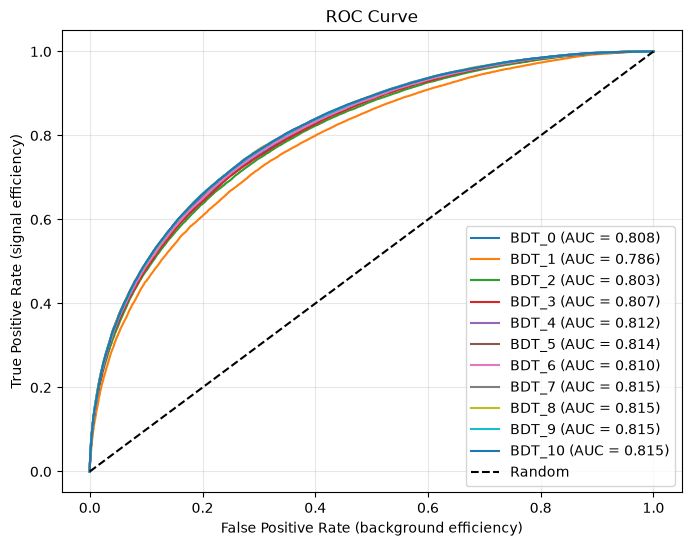

In [68]:
from sklearn.metrics import roc_curve, auc

models = [
    higgs_BDT_0,
    higgs_BDT_1,
    higgs_BDT_2,
    higgs_BDT_3, 
    higgs_BDT_4,
    higgs_BDT_5,
    higgs_BDT_6,
    higgs_BDT_7,
    higgs_BDT_8,
    higgs_BDT_9,
    higgs_BDT_10
]

plt.figure(figsize=(8, 6))

for i, model in enumerate(models):
    y_scores_i = model.predict_proba(X_test) [:, 1]
    fpr_i, tpr_i, thresholds_i = roc_curve(y_test, y_scores_i)
    auc_value_i = auc(fpr_i, tpr_i)
    plt.plot(
        fpr_i, 
        tpr_i, 
        label=f'BDT_{i} (AUC = {auc_value_i:.3f})'
    )
    
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate (background efficiency)')
plt.ylabel('True Positive Rate (signal efficiency)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Looking at the above plot and at the related AUC values, it is even more evident the performance drop observed passing from the first (higgs_BDT_0) to the second model (higgs_BDT_1) just by imposing a limit number for the trees, as it had already been observed from the accuracies. Furthermore, there are different models candidates for the one with the best performance, primarily higgs_BDT_7, higgs_BDT_9 and higgs_BDT_10. Recalling the characteristics of these Boosted Decision Trees, it should come as no surprise that higgs_BDT_7 has such a high AUC value, considering that this was the algorithm with a number of trees more than double the one of the others. Nevertheless, the results of this model, including the AUC value, don't justify the computational cost of such a high "max_iter". A similar logic can also be applied to the comparison between higgs_BDT_9 and higgs_BDT_10: as said before, changing the value of the regularization ("l2_regularization") didn't affect in a major way the models, therefore not justifying it being so high as 1. For these reasons, the Boosted Decision Tree that seems to have collected all the developments of the other models, without having ineffective complexity and bringing good performance results, appears to be higgs_BDT_9, characterised by "max_iter" = 300, "max_depth" = 7, "learning_rate" = 0.2 and "l2_regularization" = 0.1. 

Finally, for boosted decision trees it is possible to use the method "permutation_importance" to estimate the weight of every feature used in the model. It simply works by randomly shuffling that feature's values across all events and measuring how much the accuracy drops. If shuffling a feature causes a big accuracy drop, that feature was important. If accuracy barely changes, the feature wasn't contributing much. The result is then given in form of an histogram with the number of bins given by the number of features in the model and the importance on the y axis representing the percentage drop of the accuracy value for that specific feature's shuffling. This method was applied only to the best-performing model identified in the previous analysis (higgs_BDT_9). 

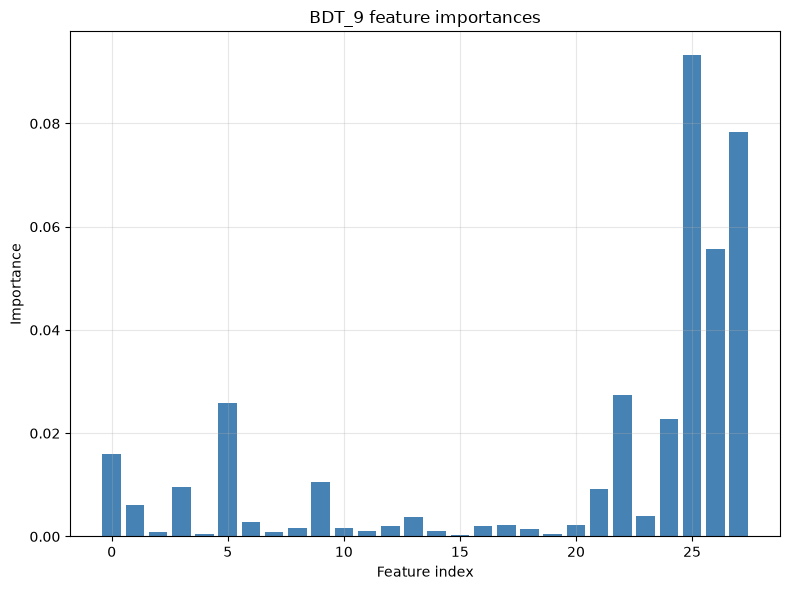

In [69]:
from sklearn.inspection import permutation_importance

plt.figure(figsize=(8, 6))

result = permutation_importance(
    higgs_BDT_9,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42
)

importances = result.importances_mean

plt.bar(
    range(len(importances)),
    importances,
    color='steelblue'
)

plt.title('BDT_9 feature importances')
plt.xlabel('Feature index')
plt.ylabel('Importance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


As it can be seen, the model seems to be highly dependent on the last features (from 22 to 28). These are high-level features, functions of the first 21, which are instead kinematic properties measured directly by the detector. The behaviour of the above plot is in line with the fact that the high-level features are purposely defined to better distinguish background and signal, so they play a larger role in the training of the models.  

To test this fact, the next two models have been trained using a reduced set of features, in order to observe if the performances of the algorithms are indeed worse when considering just the low- (higgs_BDT_9_l) or the high-level (higgs_BDT_9_h) features. higgs_BDT_9, the model which achieved the best performances, has been used both as reference and as template.

In [70]:
y_l = df.iloc[:, 0].values         
X_l = df.iloc[:, 1:22].values  

In [71]:
from sklearn.model_selection import train_test_split

X_l_train_full, X_l_test, y_l_train_full, y_l_test = train_test_split(X_l, y_l, test_size=0.2, random_state=42) 

X_l_train, X_l_val, y_l_train, y_l_val = train_test_split(X_l_train_full, y_l_train_full, test_size=0.10, random_state=42) 

In [72]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_9_l = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.2, l2_regularization=0.1)

In [73]:
%%time

higgs_BDT_9_l.fit(X_l_train, y_l_train)

CPU times: user 40.6 s, sys: 200 ms, total: 40.8 s
Wall time: 7.03 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.2
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype"

In [74]:
y_pred = higgs_BDT_9_l.predict(X_l_train)
train_acc = accuracy_score(y_l_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.704


In [75]:
y_pred = higgs_BDT_9_l.predict(X_l_val)
val_acc = accuracy_score(y_l_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.660


In [76]:
y_pred = higgs_BDT_9_l.predict(X_l_test)
test_acc = accuracy_score(y_l_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.660


In [77]:
y_h = df.iloc[:, 0].values         
X_h = df.iloc[:, 22:].values  

In [78]:
from sklearn.model_selection import train_test_split

X_h_train_full, X_h_test, y_h_train_full, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42) 

X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(X_h_train_full, y_h_train_full, test_size=0.10, random_state=42)

In [79]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier 
from sklearn.metrics import accuracy_score

higgs_BDT_9_h = HistGradientBoostingClassifier(max_bins=255, max_iter=300, validation_fraction=0.1, max_depth=7, learning_rate=0.2, l2_regularization=0.1)

In [80]:
%%time

higgs_BDT_9_h.fit(X_h_train, y_h_train)

CPU times: user 18.2 s, sys: 130 ms, total: 18.3 s
Wall time: 3.24 s


,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.2
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",7
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide <categorical_support_gbdt>`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype"

In [81]:
y_pred = higgs_BDT_9_h.predict(X_h_train)
train_acc = accuracy_score(y_h_train, y_pred)
print(f'train_acc: {train_acc:.3f}')

train_acc: 0.723


In [82]:
y_pred = higgs_BDT_9_h.predict(X_h_val)
val_acc = accuracy_score(y_h_val, y_pred)
print(f'val_acc: {val_acc:.3f}')

val_acc: 0.707


In [83]:
y_pred = higgs_BDT_9_h.predict(X_h_test)
test_acc = accuracy_score(y_h_test, y_pred)
print(f'test_acc: {test_acc:.3f}')

test_acc: 0.708


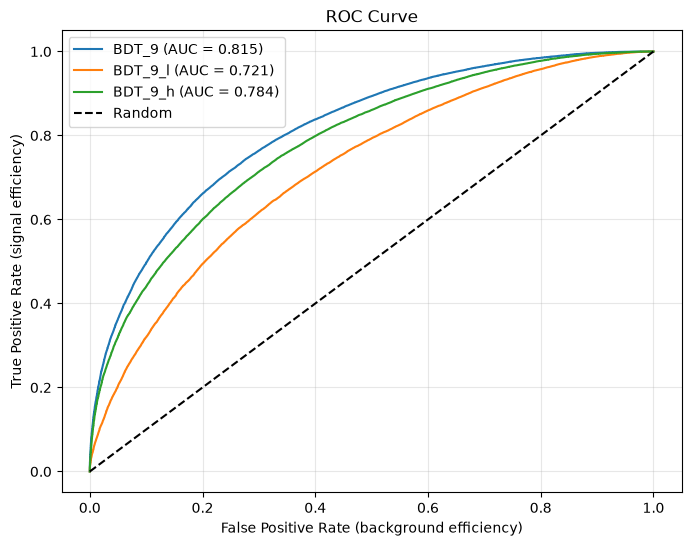

In [84]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

y_scores = higgs_BDT_9.predict_proba(X_test) [:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'BDT_9 (AUC = {auc_value:.3f})'
)

y_scores = higgs_BDT_9_l.predict_proba(X_l_test) [:, 1]
fpr, tpr, thresholds = roc_curve(y_l_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'BDT_9_l (AUC = {auc_value:.3f})'
)

y_scores = higgs_BDT_9_h.predict_proba(X_h_test) [:, 1]
fpr, tpr, thresholds = roc_curve(y_h_test, y_scores)
auc_value = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    label=f'BDT_9_h (AUC = {auc_value:.3f})'
)

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate (background efficiency)')
plt.ylabel('True Positive Rate (signal efficiency)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The above ROC curves, as well as the accuracy and AUC values, support the hypothesis: despite consisting of only seven features, the high-level feature set yields a model with better performance than the model trained exclusively on the 21 low-level features. Moreover, combining the low- and high-level features results in the best overall performance, indicating that the two feature sets provide complementary information.